<a href="https://colab.research.google.com/github/AileenOsenda/Proyecto-Ciencia-de-Datos-Observatorio-de-Conflictividad-laboral/blob/main/scrapping_laboral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SCRAPING DE DIARIOS + ANÁLISIS CON PANDAS — GOOGLE COLAB
# Temática: conflictividad laboral / palabras clave sindicales
# ============================================================

# Instalación de dependencias ──────────────────────
# !pip install requests beautifulsoup4 pandas matplotlib seaborn wordcloud


"""Celda 1 (pip install)  →  Celda 2 (imports)  →  Celda 3 (regex y categorías)
→  Celda 4 (funciones auxiliares, necesaria para clasificar_noticia)
→  Celda 7b (cargar tus Excel)  →  Celda 8 en adelante (todos los análisis)"""



'Celda 1 (pip install)  →  Celda 2 (imports)  →  Celda 3 (regex y categorías)\n→  Celda 4 (funciones auxiliares, necesaria para clasificar_noticia)\n→  Celda 7b (cargar tus Excel)  →  Celda 8 en adelante (todos los análisis)'

In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib seaborn wordcloud cloudscraper openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
import re
import time
import random
import requests
#import cloudscraper                        # Para saltear protecciones anti-bot (ej: La Voz)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from urllib.parse import urljoin           # Para resolver URLs relativas correctamente
from datetime import datetime
from collections import Counter
from wordcloud import WordCloud
from google.colab import files             # Para descargar el CSV al finalizar

In [ ]:
# ── Definición de palabras clave ─────────────────────
# Expresión regular con todos los términos de conflictividad laboral
PALABRAS_CLAVES = re.compile(
    r'\bparo[a-zA-Z]*\b|\bparan\b|\basamblea[s]?\b|\bhuelga\b|\bmarcha\b|'
    r'\bcorte[s]? de ruta\b|\bcortan ruta\b|\bcortes? de calle\b|\bcortan calle\b|'
    r'\btrabaj[a-zA-Z]*\b|\bsindica[a-zA-Z]*\b|\bparitari[a-zA-Z]*\b|\bgremi[a-zA-Z]*\b|'
    r'\bcgt\b|\buta\b|\bate\b|\bluz y fuerza\b|\buepc\b|\bsep\b|\butep\b|\bsurrbac\b|'
    r'\beconomia popular\b|\beconomia informal\b|\bconflicto\b|\bdespid[a-zA-Z]*\b|'
    r'\bsalar[a-zA-Z]*\b|\btransporte\b|\baguinaldo\b|\bsueldo\b|\bbancaria\b|'
    r'\bdelegad[a-zA-Z]*\b|\blimpieza\b|\bprecariza[a-zA-Z]*\b|\bcadete\b|\bsuoem\b|'
    r'\brepartidor[a-zA-Z]*\b|\baplicaciones\b|\bsuspen[a-zA-Z]*\b|\blaboral[a-zA-Z]*\b|\bdesempleo[a-zA-Z]*\b|'
    r'\bdesocup[a-zA-Z]*\b|\bretiro[s]? voluntario[s]?\b|\badiuc\b|\bdocente[s]?\b|\buber\b|\bglovo\b|\bpedidos ya\b|'
    r'\brapipago\b|\bcrisis\b|\bcobrar[a-zA-Z]*\b|\bjubilados\b|\bfabrica[s]?\b|\bindustria[s]?\b|\bempleados?\b|'
    r'\bconvenio[s]?\b|\bnegociacion\b|\bconflicto[s]?\b|\breclamo[s]?\b|\bprotesta[s]?\b|'
    r'\bquiebra\b|\brecorte\b|\bajuste\b|\bdespidos?\b|\bcierre[s]?\b|\bdespido[s]?\b|\bdesocupacion\b|\bdesempleo\b|'
    r'\bconciliacion\b|\bmoviliz[a-zA-Z]*\b|\bajuste\b|\bprotest[a-zA-Z]*\b|\bderechos?\b|\bcortes?\b',
    flags=re.IGNORECASE
)

# Diccionario de categorías temáticas para clasificar noticias
# → Permite análisis cualitativo agrupado por tipo de conflicto
CATEGORIAS = {
    "huelga_paro":      re.compile(r'\bparo[a-zA-Z]*\b|\bhuelga\b|\basamblea[s]?\b', re.IGNORECASE),
    "cortes_moviliz":   re.compile(r'\bcorte[s]?\b|\bmarcha\b|\bmoviliz[a-zA-Z]*\b', re.IGNORECASE),
    "sindicatos":       re.compile(r'\bsindica[a-zA-Z]*\b|\bcgt\b|\bgremio[s]?\b|\bdelegad[a-zA-Z]*\b', re.IGNORECASE),
    "salarios":         re.compile(r'\bsalar[a-zA-Z]*\b|\bparitari[a-zA-Z]*\b|\bsueldo\b|\baguinaldo\b', re.IGNORECASE),
    "despidos_cierre":  re.compile(r'\bdespid[a-zA-Z]*\b|\bcierre[s]?\b|\bquiebra\b|\brecorte\b', re.IGNORECASE),
    "economia_popular": re.compile(r'\beconomia popular\b|\beconomia informal\b|\brepartidor[a-zA-Z]*\b|\buber\b|\bglovo\b|\bpedidos ya\b', re.IGNORECASE),
    "docentes":         re.compile(r'\bdocente[s]?\b|\badiuc\b|\buepc\b', re.IGNORECASE),
    "desempleo":        re.compile(r'\bdesempleo\b|\bdesocup[a-zA-Z]*\b|\bdesocupacion\b', re.IGNORECASE),
}

# Pool de User-Agents reales para rotar y evitar bloqueos por bot-detection
USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:125.0) Gecko/20100101 Firefox/125.0",
    "Mozilla/5.0 (iPhone; CPU iPhone OS 17_4 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Mobile/15E148 Safari/604.1",
]




In [ ]:
# ── Funciones de scraping ───────────────────────────

# ── CELDA 4: Funciones auxiliares para análisis ───────────────
# Si no vas a correr el scraper, solo necesitás estas dos funciones.
# clasificar_noticia() la usan la celda 8 (para recalcular categorías
# si el Excel no la trae) y todas las celdas de análisis posteriores.


def clasificar_noticia(texto):
    """
    Recibe el texto de un titular y devuelve la primera categoría
    temática que coincide con los patrones definidos en CATEGORIAS.
    Si ningún patrón coincide, devuelve 'otra'.

    Se usa en la celda 8 para completar la columna 'categoria'
    cuando el Excel cargado no la incluye.
    """
    for nombre_cat, patron_cat in CATEGORIAS.items():
        if patron_cat.search(texto):
            return nombre_cat
    return "otra"


def calcular_n_palabras_clave(texto_kw):
    """
    Recibe el contenido de la columna 'palabras_clave' (string separado
    por comas, ej: "paro, sindicato, salario") y devuelve la cantidad
    de términos no vacíos.

    Se usa en la celda 8 para completar 'n_palabras_clave' si el Excel
    no la trae.
    """
    if pd.isna(texto_kw) or str(texto_kw).strip() == "":
        return 0
    return len([k for k in str(texto_kw).split(",") if k.strip()])


def enriquecer_dataframe(df):
    """
    Aplica sobre el DataFrame cargado desde Excel todas las columnas
    calculadas que necesitan los análisis, solo si no existen ya.

    Columnas que genera si faltan:
        - categoria         : categoría temática del titular
        - n_palabras_clave  : cantidad de KW en la columna palabras_clave
        - longitud_titular  : longitud en caracteres del titular
        - palabras_clave    : extrae KW del titular si la columna no existe

    Llamala siempre después de cargar el Excel (celdas 7 o 7b)
    y antes de cualquier análisis (celda 8 en adelante).
    """
    # Extraer palabras_clave del titular si la columna no viene en el Excel
    if "palabras_clave" not in df.columns:
        print("  → Columna 'palabras_clave' no encontrada, extrayendo del titular...")
        df["palabras_clave"] = df["titular"].apply(
            lambda t: ", ".join(sorted(set(
                p.lower() for p in PALABRAS_CLAVES.findall(str(t))
            ))) if pd.notna(t) else ""
        )

    # Asignar categoría temática si no existe
    if "categoria" not in df.columns:
        print("  → Columna 'categoria' no encontrada, clasificando titulares...")
        df["categoria"] = df["titular"].apply(
            lambda t: clasificar_noticia(str(t)) if pd.notna(t) else "otra"
        )

    # Calcular n_palabras_clave si no existe
    if "n_palabras_clave" not in df.columns:
        print("  → Calculando 'n_palabras_clave'...")
        df["n_palabras_clave"] = df["palabras_clave"].apply(calcular_n_palabras_clave)

    # Calcular longitud del titular si no existe
    if "longitud_titular" not in df.columns:
        print("  → Calculando 'longitud_titular'...")
        df["longitud_titular"] = df["titular"].apply(
            lambda t: len(str(t)) if pd.notna(t) else 0
        )

    print(f"\nDataFrame listo: {len(df)} filas, {len(df.columns)} columnas")
    print(f"Columnas disponibles: {list(df.columns)}")
    return df

In [ ]:
# ── Parámetros de los diarios y ejecución ───────────

# URLs de las portadas a monitorear
DIARIOS = [
    "https://www.laizquierdadiario.com/Cordoba",
    "https://www.lavoz.com.ar/",
  # "https://www.lavoz.com.ar/negocios/"   # Descomentar para incluir sección economía
    "http://www.lavozdesanjusto.com.ar/",
    "https://www.eldiariocba.com.ar/",
    "https://www.cba24n.com.ar/",
    "https://www.puntal.com.ar/",
]

# Etiquetas de cada diario para el CSV (mismo orden que DIARIOS)
NOMBRE_DEL_DIARIO = [
    "la_izquierda",
    "la_voz_del_interior",
    "la_voz_de_san_justo",
    "el_diario_villa_maria",
    "cba24n",
    "puntal_rio_cuarto",
]

# Selectores CSS por diario: se prueban todos en orden hasta agotar los links
# Inspeccioná cada diario con F12 → Elements para ajustar o agregar selectores.
# Ejemplo: <div class="columnista"><a href="nota.html">Título</a></div>
#          → selector: "div.columnista a"
HTML_TAGS = [
    ["div.columnista a", "h2 a", "h3 a", "div a"],                            # la_izquierda
    ["h2 a", "h1 a", "article a", "main article seccion h1", "div article a", "article a"],  # la_voz_del_interior
    ["a"],                                                                     # la_voz_de_san_justo
    ["h2 a"],                                                                  # el_diario_villa_maria
    ["div a"],                                                                 # cba24n
    ["h1 a", "h2 a", "h3 a", "article a", "figure a"],                        # puntal_rio_cuarto
]

# Validación: los tres parámetros deben tener la misma longitud
assert len(DIARIOS) == len(NOMBRE_DEL_DIARIO) == len(HTML_TAGS), \
    "Error: DIARIOS, NOMBRE_DEL_DIARIO y HTML_TAGS deben tener el mismo número de elementos."

# ── Ejecución del scraping ────────────────────────────────────
todos_los_registros = []

# zip() empareja cada URL con su nombre y sus tags CSS
for url, nombre, tags in zip(DIARIOS, NOMBRE_DEL_DIARIO, HTML_TAGS):
    print(f"\nScrapeando: {nombre}  ({url})")
    print(f"  Tags a probar: {tags}")

    resultados = procesar_diario(url, nombre, tags)
    todos_los_registros.extend(resultados)

    print(f"  → {len(resultados)} noticias relevantes encontradas")

print(f"\n{'═'*50}")
print(f"Total de noticias recolectadas: {len(todos_los_registros)}")


Scrapeando: la_izquierda  (https://www.laizquierdadiario.com/Cordoba)
  Tags a probar: ['div.columnista a', 'h2 a', 'h3 a', 'div a']
  → 4 noticias relevantes encontradas

Scrapeando: la_voz_del_interior  (https://www.lavoz.com.ar/)
  Tags a probar: ['h2 a', 'h1 a', 'article a', 'main article seccion h1', 'div article a', 'article a']
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
[ERROR] get_scraping_links(https://www.lavoz.com.ar/): name 'cloudscraper' is not defined
  → 0 noticias relevantes encontradas

Scrapeando: la_voz_de_san_justo  (http://www.lavozdesanjusto.com.ar/)
  Tags a prob

In [ ]:
# ── CELDA 6: Crear y guardar el DataFrame / Excel ─────────────

df = pd.DataFrame(todos_los_registros)
df = df.drop_duplicates(subset=["titular", "diario"])

NOMBRE_ARCHIVO = f"scraping_laboral_{datetime.now().strftime('%Y%m%d')}.xlsx"

# Requiere openpyxl: !pip install openpyxl
# engine="openpyxl" es el motor estándar para escribir .xlsx con pandas
df.to_excel(NOMBRE_ARCHIVO, index=False, engine="openpyxl")

print(f"Excel guardado: {NOMBRE_ARCHIVO} ({len(df)} registros)")
files.download(NOMBRE_ARCHIVO)

'\n# ── Crear y guardar el DataFrame / CSV ───────────────\n# Crear DataFrame principal con todos los resultados\ndf = pd.DataFrame(todos_los_registros)\n\n# Evitar duplicados exactos (mismo titular + mismo diario)\ndf = df.drop_duplicates(subset=["titular", "diario"])\n\n# Guardar como CSV con encoding UTF-8 para caracteres en español\nNOMBRE_ARCHIVO = f"scraping_laboral_{datetime.now().strftime(\'%Y%m%d\')}.csv"\ndf.to_csv(NOMBRE_ARCHIVO, index=False, encoding="utf-8-sig")  # utf-8-sig para Excel en Windows\nprint(f"CSV guardado: {NOMBRE_ARCHIVO} ({len(df)} registros)")\n\n# Descargar el archivo al equipo local desde Colab\nfiles.download(NOMBRE_ARCHIVO)'

In [ ]:
# DIAGNÓSTICO — correr esto primero
import pandas as pd

df_raw = pd.read_excel("mayo_2026_noticias.xlsx", engine="openpyxl")
print("Columnas en tu archivo:")
print(df_raw.columns.tolist())
print("\nPrimeras 2 filas:")
print(df_raw.head(2))

Columnas en tu archivo:
['fecha', 'diario', 'link', 'palabras_claves', 'titulo', 'contenido']

Primeras 2 filas:
        fecha                                     diario  \
0  01-05-2026  https://www.laizquierdadiario.com/Cordoba   
1  01-05-2026  https://www.laizquierdadiario.com/Cordoba   

                                                link        palabras_claves  \
0  https://www.laizquierdadiario.com/Mundo-de-lxs...           trabajadorxs   
1  https://www.laizquierdadiario.com/Llaryora-des...  despide salarios uepc   

                                              titulo  \
0                          Mundo de l@s trabajador@s   
1  Córdoba. Llaryora despide y ajusta salarios, l...   

                                           contenido  
0                            Se pelea en las calles.  
1  La conducción provincial de UEPC está atada al...  


In [ ]:
# ──Cargar CSV existente (para análisis posterior) ───
# USAR esta celda:
# from google.colab import files
# uploaded = files.upload()
# nombre_csv = list(uploaded.keys())[0]
# df = pd.read_csv(nombre_csv, encoding="utf-8-sig")


# ╔══════════════════════════════════════════════════════════════╗
# ║              ANÁLISIS ESTADÍSTICO Y CUALITATIVO              ║
# ╚══════════════════════════════════════════════════════════════╝

In [ ]:
# ── CELDA 7 — Carga del Excel ─────────────────────────────────
import pandas as pd
from google.colab import files

uploaded = files.upload()
nombre_xlsx = list(uploaded.keys())[0]

df = pd.read_excel(nombre_xlsx, engine="openpyxl")

# Renombrar las dos columnas que difieren del esquema interno
df = df.rename(columns={
    "fecha":          "fecha_scraping",
    "titulo":         "titular",
    "link":           "url_noticia",
    # "diario", "palabras_clave" y "contenido" ya tienen el nombre correcto
})

# Normalizar fecha a datetime
df["fecha_scraping"] = pd.to_datetime(
    df["fecha_scraping"], dayfirst=True, errors="coerce"
)

# Enriquecer columnas calculadas que puedan faltar
df = enriquecer_dataframe(df)

print(f"Filas cargadas  : {len(df)}")
print(f"Rango de fechas : {df['fecha_scraping'].min().date()}  →  {df['fecha_scraping'].max().date()}")
print(f"Diarios         : {sorted(df['diario'].unique())}")
df.head()

Saving mayo_2026_noticias.xlsx to mayo_2026_noticias (1).xlsx
  → Columna 'palabras_clave' no encontrada, extrayendo del titular...
  → Columna 'categoria' no encontrada, clasificando titulares...
  → Calculando 'n_palabras_clave'...
  → Calculando 'longitud_titular'...

DataFrame listo: 392 filas, 10 columnas
Columnas disponibles: ['fecha_scraping', 'diario', 'url_noticia', 'palabras_claves', 'titular', 'contenido', 'palabras_clave', 'categoria', 'n_palabras_clave', 'longitud_titular']
Filas cargadas  : 392
Rango de fechas : 2026-05-01  →  2026-05-24
Diarios         : ['http://www.lavozdesanjusto.com.ar/', 'https://www.cba24n.com.ar/', 'https://www.eldiariocba.com.ar/', 'https://www.laizquierdadiario.com/Cordoba', 'https://www.lavoz.com.ar/', 'https://www.puntal.com.ar/']


,fecha_scraping,diario,url_noticia,palabras_claves,titular,contenido,palabras_clave,categoria,n_palabras_clave,longitud_titular
0,2026-05-01,https://www.laizquierdadiario.com/Cordoba,https://www.laizquierdadiario.com/Mundo-de-lxs...,trabajadorxs,Mundo de l@s trabajador@s,Se pelea en las calles.,trabajador,otra,1,25
1,2026-05-01,https://www.laizquierdadiario.com/Cordoba,https://www.laizquierdadiario.com/Llaryora-des...,despide salarios uepc,"Córdoba. Llaryora despide y ajusta salarios, l...",La conducción provincial de UEPC está atada al...,"despide, salarios, uepc",salarios,3,103
2,2026-05-01,https://www.laizquierdadiario.com/Cordoba,https://www.laizquierdadiario.com/Asambleas-de...,asambleas,Asambleas del PTS FITU,Plenario nacional. Pan y Rosas se prepara para...,asambleas,huelga_paro,1,22
3,2026-05-01,https://www.laizquierdadiario.com/Cordoba,https://www.laizquierdadiario.com/Juventud-Tra...,trabajadora,Juventud Trabajadora,Corresponsal de La Red - La Plata,trabajadora,otra,1,20
4,2026-05-01,https://www.lavoz.com.ar/,https://www.lavoz.com.ar/politica/industria-im...,industria,NaN,NaN,,otra,0,0


In [ ]:
# ── CELDA 7b: Cargar múltiples Excel y unificar ───────────────
# Útil si tenés un archivo por diario, por mes, o por período de scraping.

from google.colab import files
import io

uploaded = files.upload()   # Seleccionás todos los archivos juntos (Ctrl+clic)

fragmentos = []
for nombre, contenido in uploaded.items():
    print(f"Cargando: {nombre}")
    try:
        # io.BytesIO permite leer los bytes subidos sin guardar en disco
        fragmento = pd.read_excel(io.BytesIO(contenido), engine="openpyxl")

        # Guardar el nombre del archivo como columna para rastrear el origen
        fragmento["archivo_origen"] = nombre
        fragmentos.append(fragmento)
        print(f"  ✓ {len(fragmento)} filas")
    except Exception as e:
        print(f"  [ERROR] No se pudo leer {nombre}: {e}")

# Concatenar todos los fragmentos en un único DataFrame
df = pd.concat(fragmentos, ignore_index=True)

# Deduplicar por titular + diario + fecha (mismo evento en archivos distintos)
antes = len(df)
df = df.drop_duplicates(subset=["titular", "diario", "fecha_scraping"])
print(f"\nTotal filas      : {antes}")
print(f"Duplicados elim. : {antes - len(df)}")
print(f"Dataset final    : {len(df)} noticias únicas")

# Normalizar fecha
df["fecha_scraping"] = pd.to_datetime(df["fecha_scraping"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["fecha_scraping"])   # Eliminar filas con fecha inválida

In [ ]:
# ── CELDA 7c: Diagnóstico de columnas (opcional) ──────────────
# Corré esto si no estás seguro de que los tres archivos tienen
# exactamente los mismos nombres de columna.

for nombre, contenido in uploaded.items():
    cols = pd.read_excel(io.BytesIO(contenido), nrows=0).columns.tolist()
    print(f"{nombre}: {cols}")

NameError: name 'io' is not defined

In [ ]:
# ── CELDA 8: Vista general del dataset ────────────────────────
# Funciona igual independientemente de si el df vino del scraper,
# de la celda 7 (un solo xlsx) o de la celda 7b (varios xlsx).

print("══ ESTRUCTURA DEL DATASET ══════════════════════")
print(df.info())

print("\n══ ESTADÍSTICAS DESCRIPTIVAS ═══════════════════")
# Si n_palabras_clave no existe (Excel viejo sin esa columna), la calculamos
if "n_palabras_clave" not in df.columns:
    df["n_palabras_clave"] = df["palabras_clave"].apply(
        lambda kw: len([k for k in str(kw).split(",") if k.strip()])
        if pd.notna(kw) else 0
    )

# Si categoria no existe, la asignamos con la función de la celda 4
if "categoria" not in df.columns:
    df["categoria"] = df["titular"].apply(
        lambda t: clasificar_noticia(str(t)) if pd.notna(t) else "otra"
    )

print(df[["n_palabras_clave", "longitud_titular"]].describe())
print(f"\nValores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])   # Solo muestra columnas con nulos

══ ESTRUCTURA DEL DATASET ══════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha_scraping    392 non-null    datetime64[ns]
 1   diario            392 non-null    object        
 2   url_noticia       392 non-null    object        
 3   palabras_claves   392 non-null    object        
 4   titular           299 non-null    object        
 5   contenido         299 non-null    object        
 6   palabras_clave    392 non-null    object        
 7   categoria         392 non-null    object        
 8   n_palabras_clave  392 non-null    int64         
 9   longitud_titular  392 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 30.8+ KB
None

══ ESTADÍSTICAS DESCRIPTIVAS ═══════════════════
       n_palabras_clave  longitud_titular
count        392.000000        

In [ ]:
# ── Frecuencia por diario ────────────────────────────
print("══ NOTICIAS POR DIARIO ══════════════════════════")
# value_counts() cuenta cuántas noticias aportó cada medio
freq_diario = df["diario"].value_counts()
print(freq_diario)

# Proporción porcentual de cada diario sobre el total
print("\n── Proporción (%) ──")
print((freq_diario / freq_diario.sum() * 100).round(2))


══ NOTICIAS POR DIARIO ══════════════════════════
diario
https://www.cba24n.com.ar/                   100
https://www.lavoz.com.ar/                     94
https://www.puntal.com.ar/                    84
https://www.eldiariocba.com.ar/               64
http://www.lavozdesanjusto.com.ar/            45
https://www.laizquierdadiario.com/Cordoba      5
Name: count, dtype: int64

── Proporción (%) ──
diario
https://www.cba24n.com.ar/                   25.51
https://www.lavoz.com.ar/                    23.98
https://www.puntal.com.ar/                   21.43
https://www.eldiariocba.com.ar/              16.33
http://www.lavozdesanjusto.com.ar/           11.48
https://www.laizquierdadiario.com/Cordoba     1.28
Name: count, dtype: float64


In [ ]:
# ── Frecuencia por categoría temática ──────────────
print("══ NOTICIAS POR CATEGORÍA ═══════════════════════")
freq_cat = df["categoria"].value_counts()
print(freq_cat)

# Tabla cruzada: diario × categoría (útil para ver qué temas cubre cada medio)
print("\n── Diario × Categoría ──")
tabla_cruzada = pd.crosstab(df["diario"], df["categoria"])
print(tabla_cruzada)

══ NOTICIAS POR CATEGORÍA ═══════════════════════
categoria
otra                249
cortes_moviliz       94
despidos_cierre      17
huelga_paro          11
salarios             11
docentes              4
sindicatos            3
economia_popular      2
desempleo             1
Name: count, dtype: int64

── Diario × Categoría ──
categoria                                  cortes_moviliz  desempleo  \
diario                                                                 
http://www.lavozdesanjusto.com.ar/                      9          0   
https://www.cba24n.com.ar/                             44          1   
https://www.eldiariocba.com.ar/                        17          0   
https://www.laizquierdadiario.com/Cordoba               0          0   
https://www.lavoz.com.ar/                               0          0   
https://www.puntal.com.ar/                             24          0   

categoria                                  despidos_cierre  docentes  \
diario                 

In [ ]:
# ── Evolución temporal ──────────────────────────────
# Convertir fecha a tipo datetime para operaciones de series de tiempo
df["fecha_scraping"] = pd.to_datetime(df["fecha_scraping"])

print("══ NOTICIAS POR FECHA ═══════════════════════════")
# Agrupar por fecha y contar noticias por día
serie_temporal = df.groupby("fecha_scraping").size().rename("n_noticias")
print(serie_temporal)

# Estadísticas de la serie temporal
print(f"\n  Promedio diario  : {serie_temporal.mean():.1f} noticias")
print(f"  Día más activo   : {serie_temporal.idxmax().date()} ({serie_temporal.max()} noticias)")
print(f"  Día menos activo : {serie_temporal.idxmin().date()} ({serie_temporal.min()} noticias)")

══ NOTICIAS POR FECHA ═══════════════════════════
fecha_scraping
2026-05-01    25
2026-05-02    15
2026-05-03     6
2026-05-04    18
2026-05-05    10
2026-05-06    21
2026-05-07    25
2026-05-08    12
2026-05-09    20
2026-05-10     8
2026-05-11    19
2026-05-12    34
2026-05-13    27
2026-05-14    10
2026-05-15    10
2026-05-16     9
2026-05-17    14
2026-05-18    18
2026-05-19    19
2026-05-20    16
2026-05-21    21
2026-05-22    18
2026-05-23    10
2026-05-24     7
Name: n_noticias, dtype: int64

  Promedio diario  : 16.3 noticias
  Día más activo   : 2026-05-12 (34 noticias)
  Día menos activo : 2026-05-03 (6 noticias)


In [ ]:
# ── Análisis de palabras clave individuales ─────────
# Expandir la columna "palabras_clave" (que tiene listas separadas por coma)
# en una Serie plana con cada palabra como elemento individual
todas_las_kw = (
    df["palabras_clave"]
    .dropna()
    .str.split(", ")                  # Separar por coma
    .explode()                        # Una fila por palabra
    .str.strip()
    .str.lower()
)

# Top 20 palabras más frecuentes en el corpus
top_kw = todas_las_kw.value_counts().head(20)
print("══ TOP 20 PALABRAS CLAVE MÁS FRECUENTES ═════════")
print(top_kw)

# Riqueza léxica: cuántas palabras clave únicas aparecen
print(f"\nTotal de palabras clave únicas: {todas_las_kw.nunique()}")



══ TOP 20 PALABRAS CLAVE MÁS FRECUENTES ═════════
palabras_clave
                108
marcha           40
cortes           29
corte            27
crisis           17
trabajo          17
laboral          16
trabajadores     13
industria        11
recorte          10
trabajador        9
paro              8
reclamo           8
transporte        7
ajuste            6
jubilados         6
empleados         6
salario           5
despidos          4
sep               4
Name: count, dtype: int64

Total de palabras clave únicas: 67


In [ ]:
# ── Intensidad de cobertura ─────────────────────────
# n_palabras_clave es un proxy de qué tan "densa" es la noticia en términos laborales
print("══ INTENSIDAD DE COBERTURA (KW por noticia) ═════")
print(df["n_palabras_clave"].describe())

# Noticias de alta densidad: más de 3 palabras clave (las más relevantes)
alta_densidad = df[df["n_palabras_clave"] >= 3]
print(f"\nNoticias con alta densidad (≥3 KW): {len(alta_densidad)}")
print(alta_densidad[["diario", "titular", "categoria", "n_palabras_clave"]].head(10))

══ INTENSIDAD DE COBERTURA (KW por noticia) ═════
count    392.000000
mean       0.831633
std        0.612921
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: n_palabras_clave, dtype: float64

Noticias con alta densidad (≥3 KW): 4
                                        diario  \
1    https://www.laizquierdadiario.com/Cordoba   
91                  https://www.cba24n.com.ar/   
247                 https://www.cba24n.com.ar/   
257                 https://www.cba24n.com.ar/   

                                               titular    categoria  \
1    Córdoba. Llaryora despide y ajusta salarios, l...     salarios   
91   ATE resolvió un paro de 24 horas para frenar l...  huelga_paro   
247  ATE protesta en aeropuertos de todo el país en...  huelga_paro   
257  Judiciales de Córdoba lanzan un plan de lucha:...  huelga_paro   

     n_palabras_clave  
1                   3  
91                  3  
247                 3  
257      

In [ ]:
# ── Análisis cualitativo — co-ocurrencia de KW ──────
# Ver qué pares de palabras clave aparecen juntos en el mismo titular
from itertools import combinations

pares = []
for _, fila in df.iterrows():
    if pd.notna(fila["palabras_clave"]):
        kws = [k.strip() for k in fila["palabras_clave"].split(",")]
        pares.extend(combinations(sorted(kws), 2))  # Todas las combinaciones de a 2

# Contar los pares más frecuentes
top_pares = Counter(pares).most_common(15)
print("══ TOP 15 PARES DE KW CO-OCURRENTES ═════════════")
for par, freq in top_pares:
    print(f"  {par[0]} + {par[1]}: {freq} veces")


══ TOP 15 PARES DE KW CO-OCURRENTES ═════════════
  corte + laboral: 5 veces
  corte + marcha: 3 veces
  crisis + trabajo: 2 veces
  corte + trabajos: 2 veces
  ate + paro: 2 veces
  suspenden + transporte: 2 veces
  crisis + trabajadores: 2 veces
  despide + salarios: 1 veces
  despide + uepc: 1 veces
  salarios + uepc: 1 veces
  despidos + trabajadores: 1 veces
  asambleas + corte de calle: 1 veces
  ate + despidos: 1 veces
  despidos + paro: 1 veces
  salarial + sep: 1 veces


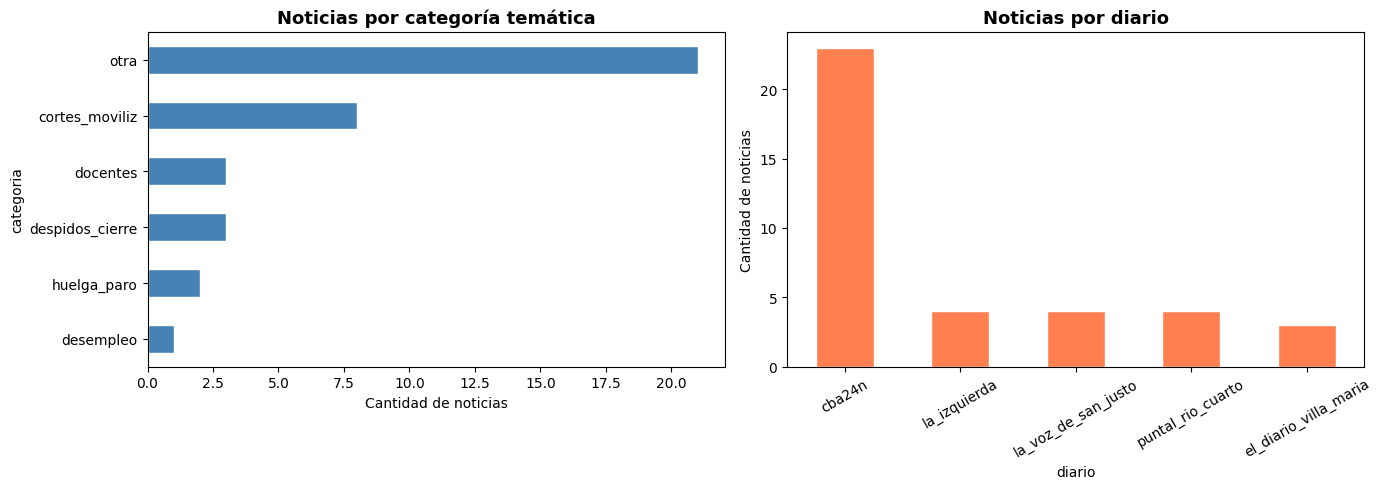

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    VISUALIZACIONES                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Gráfico de barras — noticias por categoría ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: noticias por categoría
freq_cat.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Noticias por categoría temática", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de noticias")
axes[0].invert_yaxis()  # La categoría más frecuente arriba

# Panel derecho: noticias por diario
freq_diario.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Noticias por diario", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Cantidad de noticias")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("grafico_categoria_diario.png", dpi=150)
plt.show()


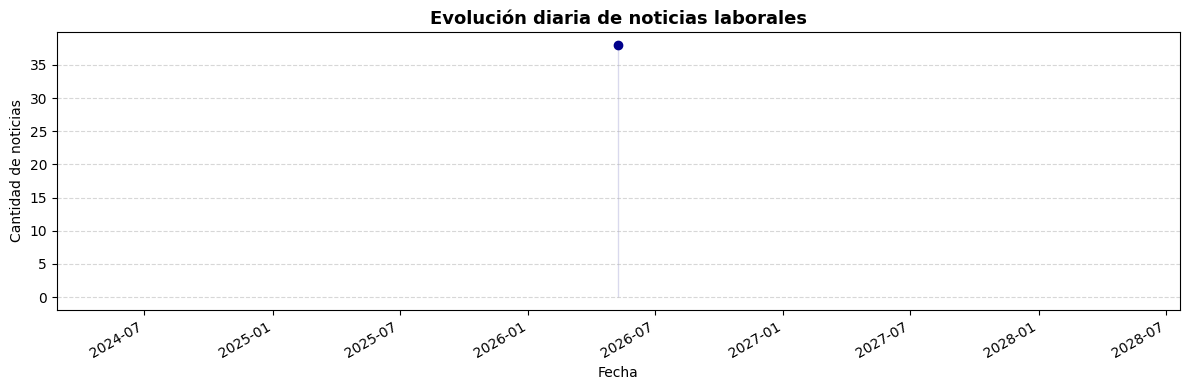

In [ ]:
# ── Serie temporal de noticias por día ──────────────
fig, ax = plt.subplots(figsize=(12, 4))

serie_temporal.plot(ax=ax, marker="o", linewidth=2, color="darkblue")
ax.fill_between(serie_temporal.index, serie_temporal.values, alpha=0.15, color="darkblue")
ax.set_title("Evolución diaria de noticias laborales", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de noticias")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("serie_temporal.png", dpi=150)
plt.show()


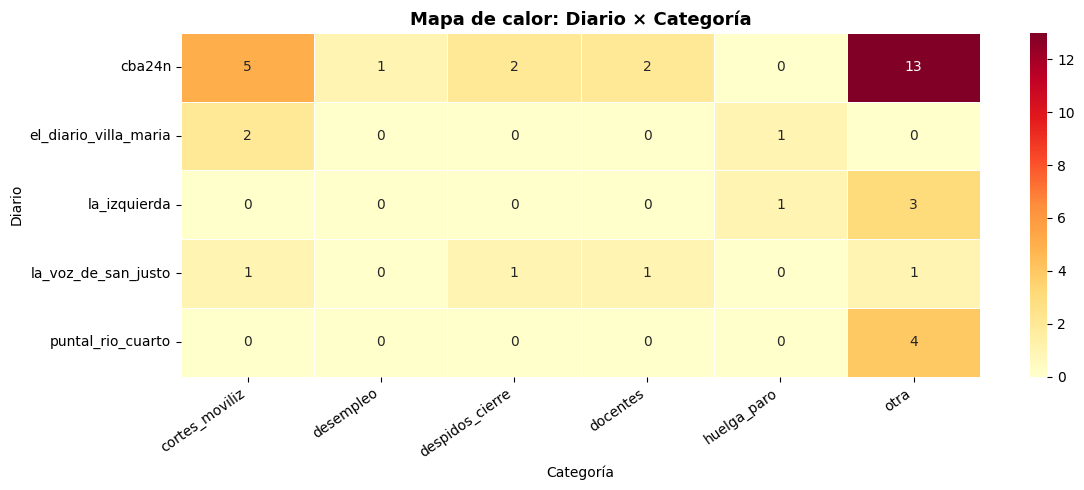

In [ ]:
# ── Heatmap — diario × categoría ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    tabla_cruzada,
    annot=True,          # Mostrar número en cada celda
    fmt="d",             # Formato entero
    cmap="YlOrRd",       # Paleta de color calor (más intenso = más noticias)
    linewidths=0.5,
    ax=ax
)
ax.set_title("Mapa de calor: Diario × Categoría", fontsize=13, fontweight="bold")
ax.set_xlabel("Categoría")
ax.set_ylabel("Diario")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("heatmap_diario_categoria.png", dpi=150)
plt.show()


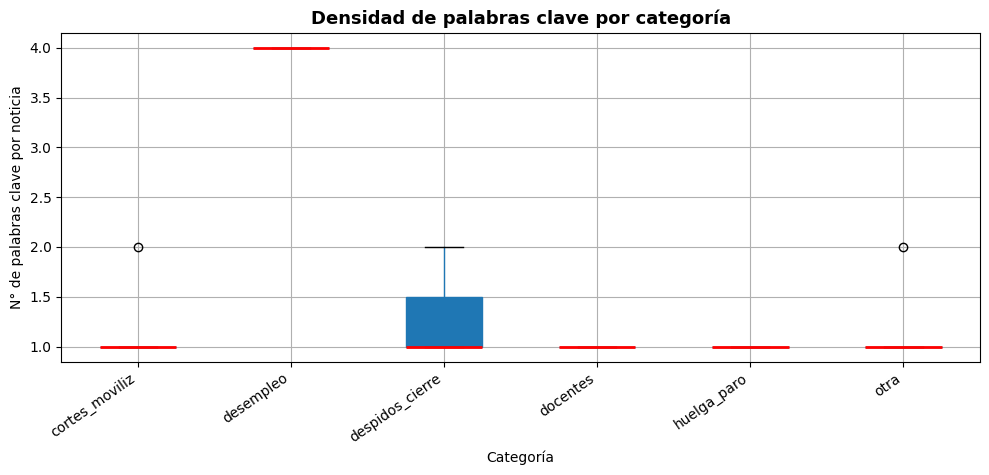

In [ ]:
# ──  Distribución de intensidad (boxplot) ────────────
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(
    column="n_palabras_clave",
    by="categoria",
    ax=ax,
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2)
)
ax.set_title("Densidad de palabras clave por categoría", fontsize=13, fontweight="bold")
ax.set_xlabel("Categoría")
ax.set_ylabel("N° de palabras clave por noticia")
plt.suptitle("")  # Eliminar título automático de pandas
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("boxplot_intensidad.png", dpi=150)
plt.show()


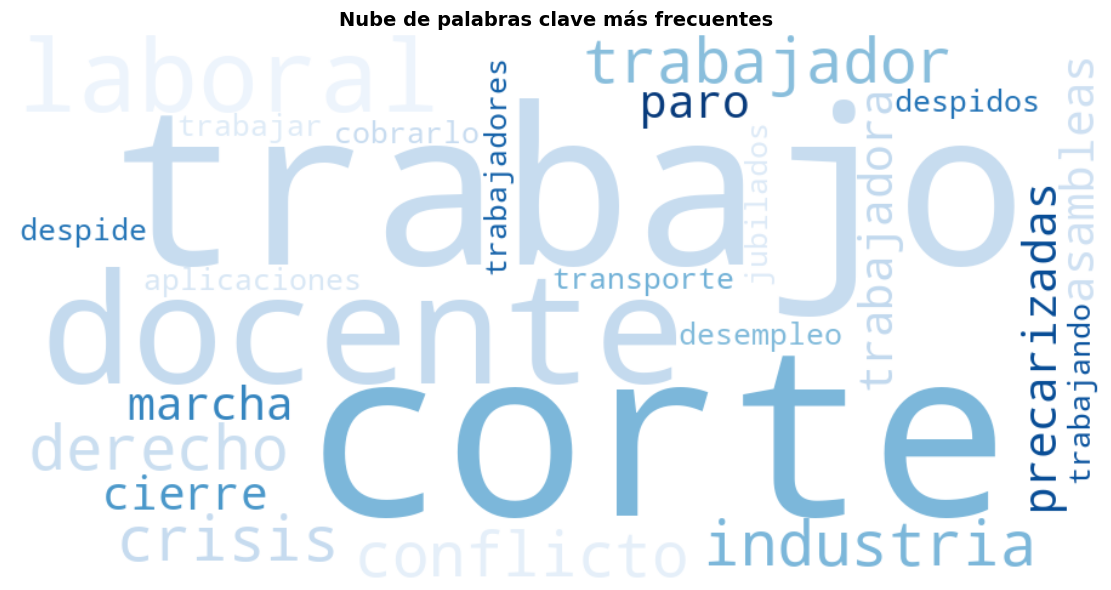

In [ ]:
# ── Nube de palabras clave ─────────────────────────
texto_nube = " ".join(todas_las_kw.tolist())

nube = WordCloud(
    width=900, height=450,
    background_color="white",
    colormap="Blues",
    max_words=80,
    collocations=False  # Evitar repetición de bigramas
).generate(texto_nube)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras clave más frecuentes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("wordcloud_kw.png", dpi=150)
plt.show()


In [ ]:
# ── Exportar análisis a CSV de resumen ─────────────
# Tabla de resumen ejecutivo que podés compartir o analizar por separado
resumen = pd.DataFrame({
    "metrica": [
        "Total noticias",
        "Noticias únicas",
        "Diarios monitoreados",
        "Categorías detectadas",
        "KW únicas en corpus",
        "Promedio KW por noticia",
        "Noticia más densa (KW)",
        "Categoría dominante",
        "Diario más activo",
    ],
    "valor": [
        len(df) + df.duplicated(subset=["titular","diario"]).sum(),  # antes de dedup
        len(df),
        df["diario"].nunique(),
        df["categoria"].nunique(),
        todas_las_kw.nunique(),
        round(df["n_palabras_clave"].mean(), 2),
        df["n_palabras_clave"].max(),
        freq_cat.idxmax(),
        freq_diario.idxmax(),
    ]
})

resumen.to_csv("resumen_ejecutivo.csv", index=False, encoding="utf-8-sig")
print("══ RESUMEN EJECUTIVO ════════════════════════════")
print(resumen.to_string(index=False))
files.download("resumen_ejecutivo.csv")


══ RESUMEN EJECUTIVO ════════════════════════════
                metrica  valor
         Total noticias     38
        Noticias únicas     38
   Diarios monitoreados      5
  Categorías detectadas      6
    KW únicas en corpus     27
Promedio KW por noticia   1.16
 Noticia más densa (KW)      4
    Categoría dominante   otra
      Diario más activo cba24n


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

══ PERFIL EDITORIAL POR DIARIO ══════════════════
categoria              cortes_moviliz  desempleo  despidos_cierre  docentes  huelga_paro   otra
diario                                                                                         
cba24n                           21.7        4.3              8.7       8.7          0.0   56.5
el_diario_villa_maria            66.7        0.0              0.0       0.0         33.3    0.0
la_izquierda                      0.0        0.0              0.0       0.0         25.0   75.0
la_voz_de_san_justo              25.0        0.0             25.0      25.0          0.0   25.0
puntal_rio_cuarto                 0.0        0.0              0.0       0.0          0.0  100.0


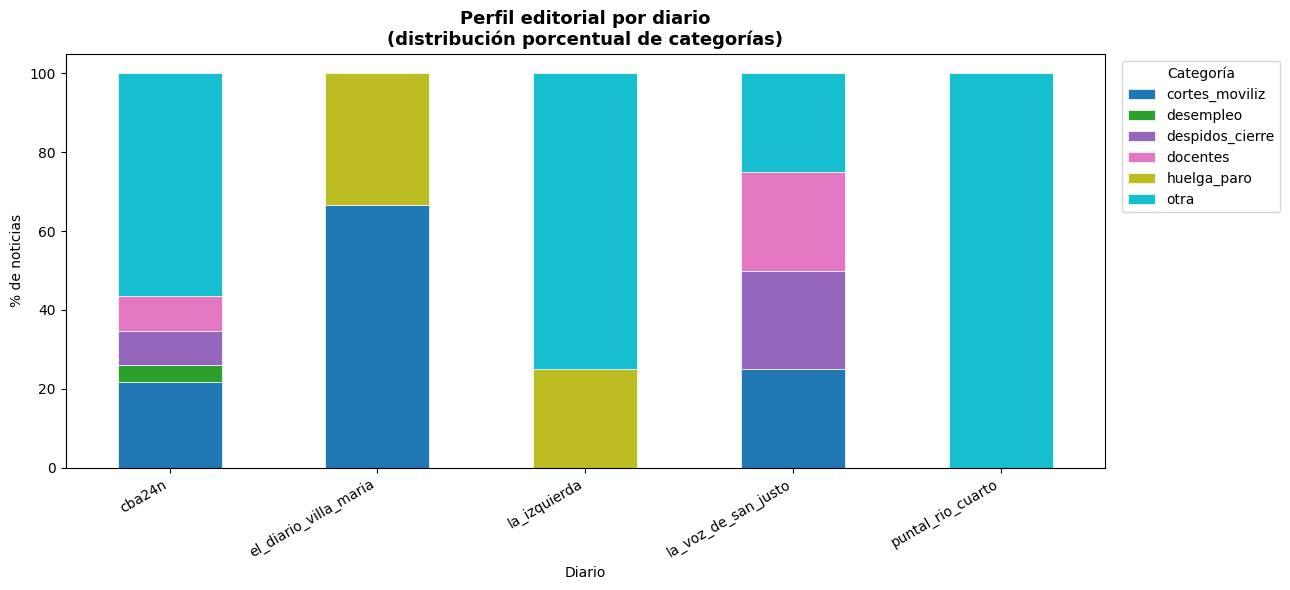


── Categoría dominante por diario ──
  cba24n                         → otra  (56.5%)
  el_diario_villa_maria          → cortes_moviliz  (66.7%)
  la_izquierda                   → otra  (75.0%)
  la_voz_de_san_justo            → cortes_moviliz  (25.0%)
  puntal_rio_cuarto              → otra  (100.0%)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              ANÁLISIS AVANZADOS (CELDAS 21–25)               ║
# ╚══════════════════════════════════════════════════════════════╝


# ── PERFIL EDITORIAL DE CADA DIARIO ─────────────────
# Pregunta: ¿Qué tipo de conflictividad laboral tematiza cada medio?
# → Permite comparar la "línea editorial" de cobertura laboral entre diarios.
# → Útil para análisis de agenda-setting: qué temas prioriza cada medio.
print("══ PERFIL EDITORIAL POR DIARIO ══════════════════")

# Tabla cruzada normalizada por fila: % de noticias de cada categoría dentro de cada diario
# normalize="index" divide cada valor por el total de su fila
perfil = pd.crosstab(df["diario"], df["categoria"], normalize="index") * 100

print(perfil.round(1).to_string())  # Mostrar con 1 decimal

# Visualización: gráfico de barras apiladas al 100%
# → Cada barra es un diario; los colores representan categorías
perfil.plot(
    kind="bar",
    stacked=True,              # Barras apiladas para ver composición proporcional
    figsize=(13, 6),
    colormap="tab10",          # Paleta con 10 colores distintos
    edgecolor="white",
    linewidth=0.5,
)
plt.title("Perfil editorial por diario\n(distribución porcentual de categorías)",
          fontsize=13, fontweight="bold")
plt.xlabel("Diario")
plt.ylabel("% de noticias")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Categoría", bbox_to_anchor=(1.01, 1), loc="upper left")  # Leyenda afuera
plt.tight_layout()
plt.savefig("perfil_editorial.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla de "especialización": categoría dominante de cada diario
dominante_por_diario = perfil.idxmax(axis=1)  # idxmax(axis=1) = columna con el % mayor por fila
print("\n── Categoría dominante por diario ──")
for diario_nombre, cat in dominante_por_diario.items():
    pct = perfil.loc[diario_nombre, cat]
    print(f"  {diario_nombre:<30} → {cat}  ({pct:.1f}%)")




══ RED DE CO-OCURRENCIA DE KW ═══════════════════
Nodos (KW únicas en red): 0
Aristas (pares co-ocurrentes): 0

── Top 10 KW más centrales en la red ──


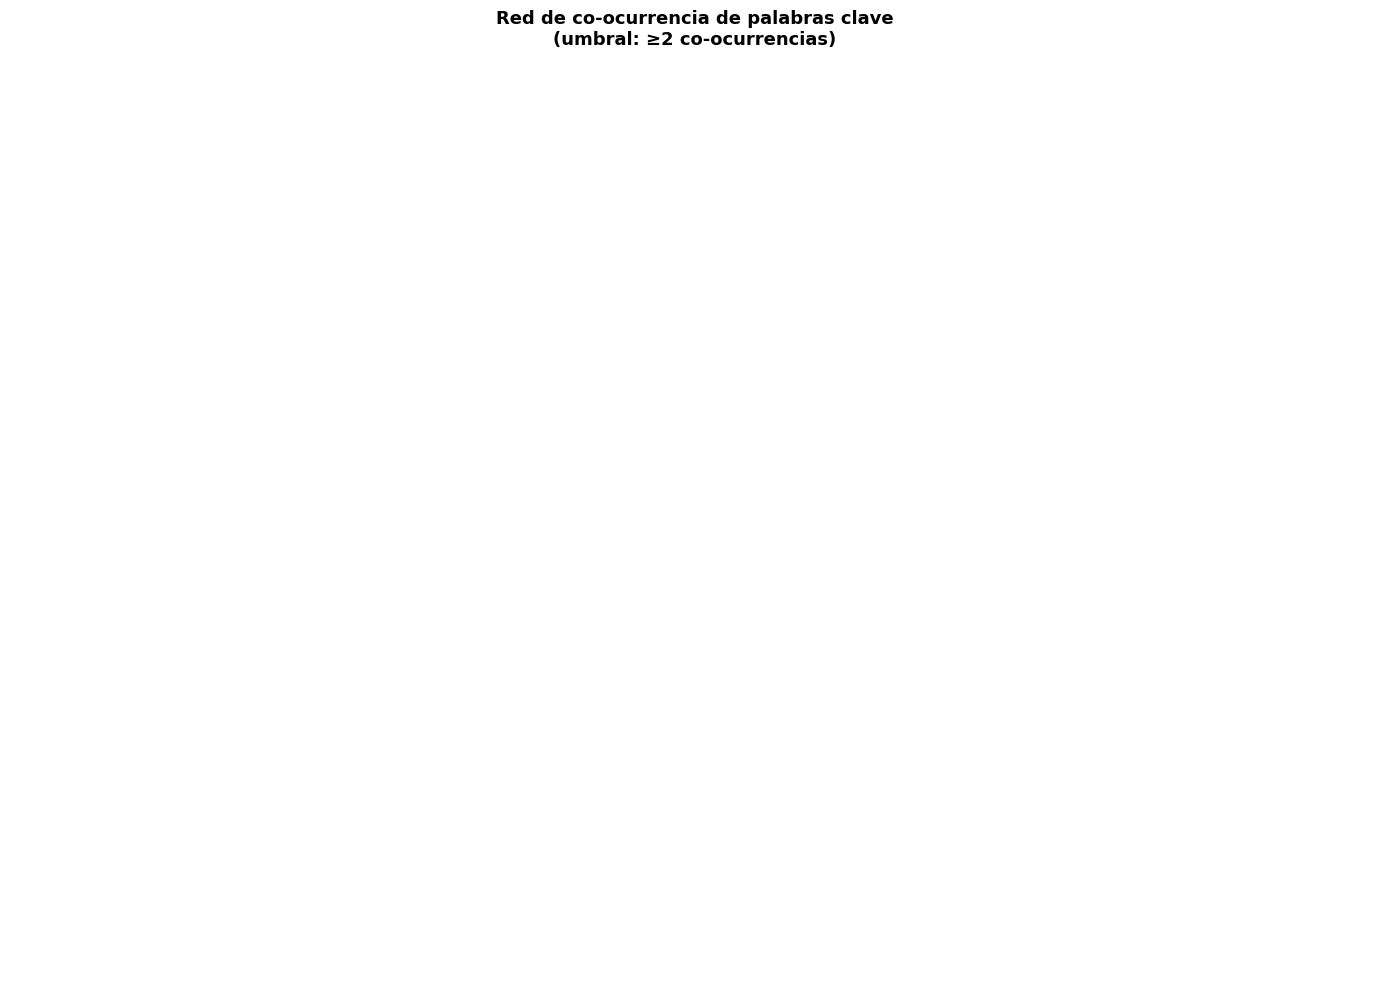

In [ ]:
# RED DE CO-OCURRENCIA DE PALABRAS CLAVE ──────────
# Pregunta: ¿Qué palabras clave aparecen juntas con más frecuencia?
# → Revela clústeres semánticos: ej. "paro" suele ir con "sindicato" o con "salario"
# → Análisis de redes aplicado al discurso de conflictividad laboral.
# !pip install networkx  ← solo si no está instalado
import networkx as nx

print("══ RED DE CO-OCURRENCIA DE KW ═══════════════════")

# Construir lista de pares de co-ocurrencia (ya calculada en celda 14)
# Si corrés esta celda sola, recalculamos:
from itertools import combinations
pares_raw = []
for _, fila in df.iterrows():
    if pd.notna(fila["palabras_clave"]):
        kws = [k.strip().lower() for k in fila["palabras_clave"].split(",") if k.strip()]
        if len(kws) > 1:
            pares_raw.extend(combinations(sorted(set(kws)), 2))  # Combinaciones únicas de a 2

conteo_pares = Counter(pares_raw)

# Umbral: solo incluir pares que co-ocurren N veces o más (reducir ruido)
UMBRAL_COOCURRENCIA = 2   # ← ajustar según el tamaño de tu corpus

# Crear grafo no dirigido
G = nx.Graph()
for (kw1, kw2), peso in conteo_pares.items():
    if peso >= UMBRAL_COOCURRENCIA:
        G.add_edge(kw1, kw2, weight=peso)

print(f"Nodos (KW únicas en red): {G.number_of_nodes()}")
print(f"Aristas (pares co-ocurrentes): {G.number_of_edges()}")

# Métricas de red: nodos más centrales (los más "conectados" al resto)
centralidad = nx.degree_centrality(G)
top_centrales = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n── Top 10 KW más centrales en la red ──")
for kw, cent in top_centrales:
    print(f"  {kw:<25} centralidad: {cent:.3f}")

# Visualización de la red
fig, ax = plt.subplots(figsize=(14, 10))

# Layout: spring_layout separa nodos conectados vs. periféricos
pos = nx.spring_layout(G, seed=42, k=1.5)

# Tamaño de nodo proporcional a su grado (cuántos otros nodos lo conectan)
grados      = dict(G.degree())
node_sizes  = [grados[n] * 200 for n in G.nodes()]

# Grosor de arista proporcional al peso (frecuencia de co-ocurrencia)
pesos_aristas = [G[u][v]["weight"] for u, v in G.edges()]
max_peso      = max(pesos_aristas) if pesos_aristas else 1

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="steelblue",
                       alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white",
                        font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos,
                       width=[p / max_peso * 4 for p in pesos_aristas],
                       alpha=0.4, edge_color="gray", ax=ax)

ax.set_title(f"Red de co-ocurrencia de palabras clave\n(umbral: ≥{UMBRAL_COOCURRENCIA} co-ocurrencias)",
             fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("red_coocurrencia.png", dpi=150)
plt.show()



══ ÍNDICE DE DIVERSIDAD TEMÁTICA (SHANNON) ══════
Entropía máxima posible (con 6 categorías): 2.58 bits

diario
la_voz_de_san_justo      2.000
cba24n                   1.753
el_diario_villa_maria    0.918
la_izquierda             0.811
puntal_rio_cuarto       -0.000

── Interpretación ──
  Más diverso  : la_voz_de_san_justo (2.00 bits)
  Menos diverso: puntal_rio_cuarto (-0.00 bits)


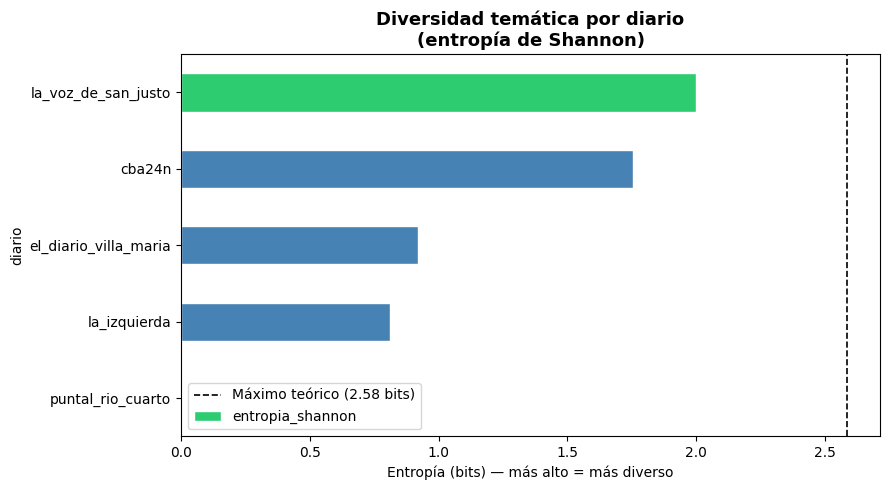

In [ ]:

# ── ÍNDICE DE DIVERSIDAD TEMÁTICA POR DIARIO ────────
# Pregunta: ¿Qué tan variada es la cobertura laboral de cada medio?
# → Un medio que solo habla de "salarios" tiene baja diversidad;
#   uno que cubre huelgas, despidos, economía popular, etc., tiene alta diversidad.
# → Se usa la entropía de Shannon, un indicador estándar de diversidad de información.
print("══ ÍNDICE DE DIVERSIDAD TEMÁTICA (SHANNON) ══════")

def entropia_shannon(serie):
    """
    Calcula la entropía de Shannon de una distribución de frecuencias.
    H = -∑ p_i * log2(p_i)
    Valores más altos = más diversidad temática.
    Máximo teórico = log2(n_categorías).
    """
    proporciones = serie / serie.sum()               # Convertir a probabilidades
    proporciones = proporciones[proporciones > 0]    # Ignorar categorías con 0 (log(0) indefinido)
    return -(proporciones * np.log2(proporciones)).sum()

# Calcular la entropía para cada diario
entropia_por_diario = (
    df.groupby("diario")["categoria"]
    .value_counts()                    # Frecuencia de cada categoría dentro del diario
    .unstack(fill_value=0)             # Convertir a tabla diario × categoría
    .apply(entropia_shannon, axis=1)   # Aplicar entropía fila por fila
    .rename("entropia_shannon")
    .sort_values(ascending=False)
)

# Entropía máxima posible (todos los temas con igual frecuencia)
n_categorias  = df["categoria"].nunique()
entropia_max  = np.log2(n_categorias)

print(f"Entropía máxima posible (con {n_categorias} categorías): {entropia_max:.2f} bits\n")
print(entropia_por_diario.round(3).to_string())
print("\n── Interpretación ──")
print(f"  Más diverso  : {entropia_por_diario.idxmax()} ({entropia_por_diario.max():.2f} bits)")
print(f"  Menos diverso: {entropia_por_diario.idxmin()} ({entropia_por_diario.min():.2f} bits)")

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#2ecc71" if v == entropia_por_diario.max()
           else "#e74c3c" if v == entropia_por_diario.min()
           else "steelblue"
           for v in entropia_por_diario]
entropia_por_diario.plot(kind="barh", ax=ax, color=colores, edgecolor="white")
ax.axvline(x=entropia_max, color="black", linestyle="--", linewidth=1.2,
           label=f"Máximo teórico ({entropia_max:.2f} bits)")
ax.set_title("Diversidad temática por diario\n(entropía de Shannon)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Entropía (bits) — más alto = más diverso")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("diversidad_tematica.png", dpi=150)
plt.show()


══ ACTORES SINDICALES MENCIONADOS ════════════════
   actor  menciones  n_diarios                     diarios
Docentes          3          2 la_voz_de_san_justo, cba24n


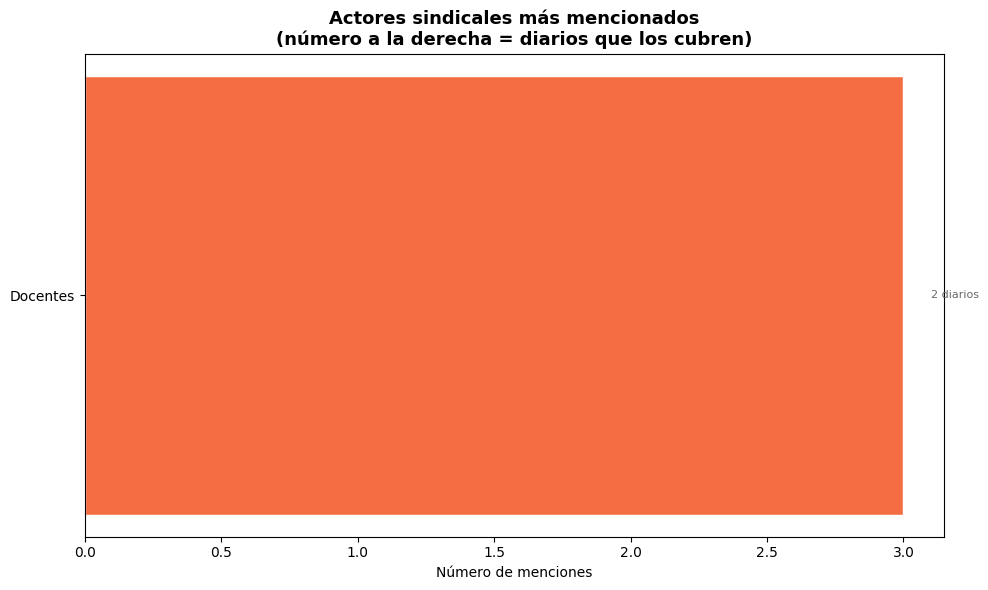

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── ANÁLISIS DE ACTORES SINDICALES MENCIONADOS ──────
# Pregunta: ¿Qué organizaciones sindicales / gremios específicos aparecen más?
# → Identifica qué actores laborales son más visibles en la cobertura.
# → Combina análisis cuantitativo (frecuencia) con cualitativo (qué medios los nombran).
print("══ ACTORES SINDICALES MENCIONADOS ════════════════")

# Diccionario de actores: nombre legible → patrón regex de búsqueda
# Podés agregar cualquier organización que te interese rastrear
ACTORES = {
    "CGT":           re.compile(r'\bcgt\b',                    re.IGNORECASE),
    "ATE":           re.compile(r'\bate\b',                    re.IGNORECASE),
    "UTA":           re.compile(r'\buta\b',                    re.IGNORECASE),
    "Luz y Fuerza":  re.compile(r'\bluz y fuerza\b',           re.IGNORECASE),
    "UEPC":          re.compile(r'\buepc\b',                   re.IGNORECASE),
    "SEP":           re.compile(r'\bsep\b',                    re.IGNORECASE),
    "UTEP":          re.compile(r'\butep\b',                   re.IGNORECASE),
    "SURRBAC":       re.compile(r'\bsurrbac\b',                re.IGNORECASE),
    "SUOEM":         re.compile(r'\bsuoem\b',                  re.IGNORECASE),
    "ADIUC":         re.compile(r'\badiuc\b',                  re.IGNORECASE),
    "Docentes":      re.compile(r'\bdocente[s]?\b',            re.IGNORECASE),
    "Uber/Glovo":    re.compile(r'\buber\b|\bglovo\b|\bpedidos ya\b', re.IGNORECASE),
}

# Para cada actor, contar en cuántas noticias aparece y en qué diarios
filas_actores = []
for actor, patron in ACTORES.items():
    mask      = df["titular"].str.contains(patron, regex=True, na=False)
    menciones = mask.sum()                    # Total de noticias con este actor
    if menciones == 0:
        continue
    diarios_que_lo_cubren = df[mask]["diario"].unique().tolist()
    filas_actores.append({
        "actor":          actor,
        "menciones":      menciones,
        "n_diarios":      len(diarios_que_lo_cubren),  # Cuántos medios lo cubren
        "diarios":        ", ".join(diarios_que_lo_cubren),
    })

df_actores = (
    pd.DataFrame(filas_actores)
    .sort_values("menciones", ascending=False)
    .reset_index(drop=True)
)
print(df_actores.to_string(index=False))

# Visualización: barras horizontales coloreadas por cobertura mediática
fig, ax = plt.subplots(figsize=(10, 6))
colores_actores = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(df_actores))   # Gradiente verde (muchos medios) a rojo (pocos)
)
bars = ax.barh(df_actores["actor"], df_actores["menciones"],
               color=colores_actores[::-1], edgecolor="white")

# Anotar cuántos diarios cubren cada actor
for bar, n_d in zip(bars, df_actores["n_diarios"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{n_d} diario{'s' if n_d != 1 else ''}",
            va="center", fontsize=8, color="dimgray")

ax.set_title("Actores sindicales más mencionados\n(número a la derecha = diarios que los cubren)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Número de menciones")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("actores_sindicales.png", dpi=150)
plt.show()

# Exportar tabla de actores para uso externo
df_actores.to_csv("actores_sindicales.csv", index=False, encoding="utf-8-sig")
files.download("actores_sindicales.csv")


══ SCORE DE RELEVANCIA Y TOP NOTICIAS ═══════════
── Top 20 noticias más relevantes ──
  #01  score=0.436  [cba24n]  asistencia Seguro de desempleo de ANSES: quiénes pueden cobrarlo, requisitos y c…
  #02  score=0.361  [cba24n]  Declaraciones Carlos Rosenkrantz en Córdoba: “Los argentinos debemos confiar más…
  #03  score=0.349  [cba24n]  podcast Futuros (im)posibles, episodio 1: Diego Speroni y el futuro en el espaci…
  #04  score=0.341  [cba24n]  Podcast Futuros (im)posibles, episodio 9: el futuro de las redes sociales con Ju…
  #05  score=0.314  [la_voz_de_san_justo]  Desafíos de la formación docente
  #06  score=0.282  [cba24n]  Trabajo Denuncian despidos en el Jockey Club de Córdoba Esta semana comenzaron a…
  #07  score=0.252  [el_diario_villa_maria]  Paro en el Central y el Hipotecario
  #08  score=0.250  [la_izquierda]  Asambleas del PTS
  #09  score=0.224  [cba24n]  Fútbol Banderazo de Belgrano: los hinchas del Pirata alentaron antes del clásico…
  #10  score=0.218  [cba24n]  

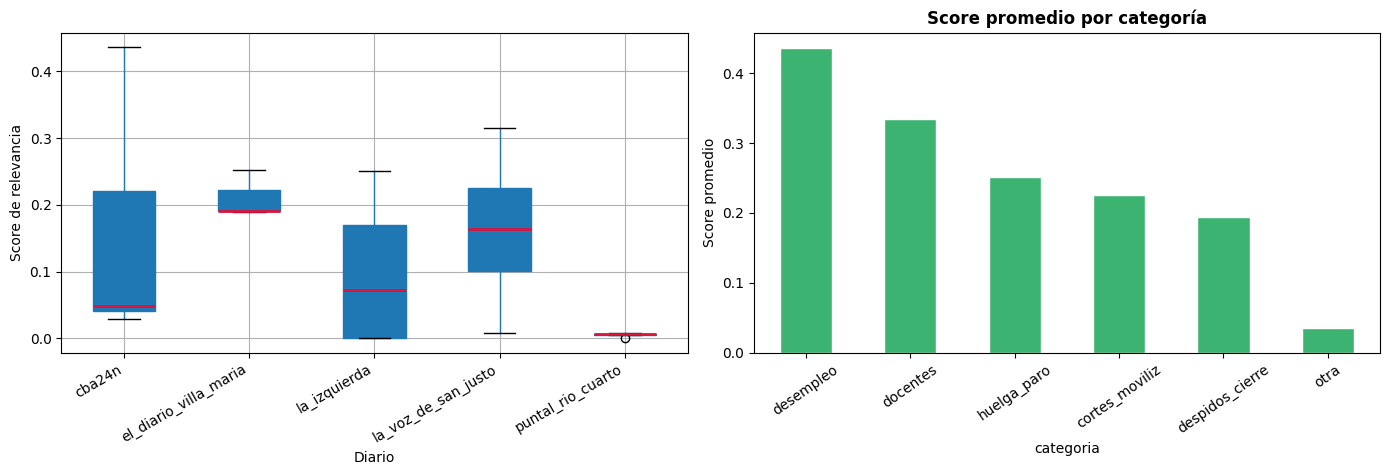


Ranking completo exportado: 38 noticias


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── SCORE DE RELEVANCIA Y RANKING DE NOTICIAS ───────
# Pregunta: ¿Cuál es la noticia más "importante" del corpus?
# → Se construye un score compuesto que pondera múltiples dimensiones:
#     • Densidad de palabras clave (más KW = más central al tema)
#     • Presencia de actores sindicales (más actores = más institucional)
#     • Categoría de alta conflictividad (huelgas y cortes pesan más)
#     • Longitud del titular (titulares más informativos)
print("══ SCORE DE RELEVANCIA Y TOP NOTICIAS ═══════════")

# Pesos por categoría: escala del 1 al 5 según conflictividad potencial
# → Ajustá los pesos según tu criterio teórico o hipótesis de investigación
PESO_CATEGORIA = {
    "huelga_paro":      5,   # Máxima conflictividad: paro / huelga
    "cortes_moviliz":   4,   # Alta conflictividad: cortes de calle/ruta
    "sindicatos":       3,   # Media: acción sindical organizada
    "despidos_cierre":  3,   # Media: reestructuración laboral
    "salarios":         2,   # Baja-media: disputa salarial
    "docentes":         2,
    "economia_popular": 2,
    "desempleo":        1,
    "otra":             1,
}

# Contar cuántos actores sindicales aparecen en cada titular
def contar_actores(texto):
    """Devuelve cuántos actores del dict ACTORES están presentes en el titular."""
    return sum(1 for patron in ACTORES.values() if patron.search(texto))

df["n_actores"]     = df["titular"].apply(contar_actores)
df["peso_categoria"] = df["categoria"].map(PESO_CATEGORIA).fillna(1)

# Fórmula del score compuesto (todos los componentes normalizados al rango [0,1])
# → Normalizar evita que una variable domine por su escala
def normalizar(serie):
    """Min-max normalization: lleva los valores al rango [0, 1]."""
    rango = serie.max() - serie.min()
    return (serie - serie.min()) / rango if rango > 0 else serie * 0

df["score"] = (
    normalizar(df["n_palabras_clave"]) * 0.40   # 40%: densidad de KW laborales
    + normalizar(df["n_actores"])       * 0.25  # 25%: actores sindicales mencionados
    + normalizar(df["peso_categoria"])  * 0.25  # 25%: gravedad de la categoría
    + normalizar(df["longitud_titular"])* 0.10  # 10%: extensión informativa del titular
).round(4)

# Top 20 noticias más relevantes según el score
top20 = (
    df[["score", "diario", "categoria", "n_palabras_clave", "n_actores", "titular", "url_noticia"]]
    .sort_values("score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20.index += 1   # Ranking desde 1

print("── Top 20 noticias más relevantes ──")
# Imprimir de forma legible: score + diario + titular truncado
for i, row in top20.iterrows():
    titular_corto = row["titular"][:80] + "…" if len(row["titular"]) > 80 else row["titular"]
    print(f"  #{i:02d}  score={row['score']:.3f}  [{row['diario']}]  {titular_corto}")

# Distribución del score por diario (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: distribución del score por diario
df.boxplot(
    column="score", by="diario",
    ax=axes[0],
    patch_artist=True,
    medianprops=dict(color="crimson", linewidth=2)
)
axes[0].set_title("Distribución del score por diario", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Diario")
axes[0].set_ylabel("Score de relevancia")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.sca(axes[0]); plt.title("")   # Quitar el título automático de pandas
plt.sca(axes[0]); plt.suptitle("")

# Panel derecho: score promedio por categoría (barras ordenadas)
score_por_cat = df.groupby("categoria")["score"].mean().sort_values(ascending=False)
score_por_cat.plot(kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="white")
axes[1].set_title("Score promedio por categoría", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score promedio")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("")   # Eliminar el suptitle global de pandas
plt.tight_layout()
plt.savefig("score_relevancia.png", dpi=150)
plt.show()

# Exportar el ranking completo para análisis cualitativo posterior
df_ranking = df.sort_values("score", ascending=False).reset_index(drop=True)
df_ranking.index += 1
df_ranking.to_csv("ranking_noticias.csv", index_label="ranking", encoding="utf-8-sig")
print(f"\nRanking completo exportado: {len(df_ranking)} noticias")
files.download("ranking_noticias.csv")


In [ ]:
# ── CARGA Y NORMALIZACIÓN DE MÚLTIPLES EXCEL ────────
# Objetivo: unificar varios archivos .xlsx de scraping histórico en un único
# DataFrame con la misma estructura que genera el scraper actual.
#
# Columnas esperadas en los Excel del usuario:
#   Fecha | diario | link | palabras_claves | titulo | contenido
#
# Se mapean a los nombres internos del proyecto:
#   fecha_scraping | diario | url_noticia | palabras_clave | titular | contenido
# ─────────────────────────────────────────────────────────────

# Mapa de normalización: nombre original en el Excel → nombre interno del proyecto
# Ajustá las claves si algún archivo usa nombres ligeramente distintos
MAPA_COLUMNAS = {
    # variantes de "fecha"
    "fecha":             "fecha_scraping",
    "Fecha":             "fecha_scraping",
    "FECHA":             "fecha_scraping",
    "date":              "fecha_scraping",
    # variantes de "diario"
    "diario":            "diario",
    "Diario":            "diario",
    "medio":             "diario",
    "Medio":             "diario",
    "fuente":            "diario",
    # variantes de "link"
    "link":              "url_noticia",
    "Link":              "url_noticia",
    "url":               "url_noticia",
    "URL":               "url_noticia",
    # variantes de "palabras_claves"
    "palabras_claves":   "palabras_clave",
    "palabras_clave":    "palabras_clave",
    "Palabras_claves":   "palabras_clave",
    "keywords":          "palabras_clave",
    # variantes de "titulo"
    "titulo":            "titular",
    "Titulo":            "titular",
    "título":            "titular",
    "Título":            "titular",
    "titular":           "titular",
    "Titular":           "titular",
    # variantes de "contenido"
    "contenido":         "contenido",
    "Contenido":         "contenido",
    "texto":             "contenido",
    "Texto":             "contenido",
    "cuerpo":            "contenido",
}

# Columnas mínimas necesarias para que el DataFrame sea válido
COLUMNAS_REQUERIDAS = ["fecha_scraping", "diario", "titular"]


def cargar_excel(ruta: str, nombre_archivo: str) -> pd.DataFrame:
    """
    Lee un archivo .xlsx, normaliza sus columnas y aplica los enriquecimientos
    (categoría, n_palabras_clave, longitud_titular) para que sea compatible
    con el DataFrame generado por el scraper.

    Parámetros:
        ruta           : Ruta al archivo en el sistema de Colab
        nombre_archivo : Nombre del archivo (solo para mensajes de log)

    Retorna:
        DataFrame normalizado, o DataFrame vacío si hay un error crítico.
    """
    try:
        df_raw = pd.read_excel(ruta)
    except Exception as e:
        print(f"  [ERROR] No se pudo leer '{nombre_archivo}': {e}")
        return pd.DataFrame()

    # Renombrar columnas usando el mapa de normalización
    df_raw = df_raw.rename(columns=MAPA_COLUMNAS)

    # Verificar que estén las columnas mínimas
    faltantes = [c for c in COLUMNAS_REQUERIDAS if c not in df_raw.columns]
    if faltantes:
        print(f"  [WARN] '{nombre_archivo}' no tiene columnas requeridas: {faltantes}. Se omite.")
        return pd.DataFrame()

    # ── Estandarizar fecha ────────────────────────────────────
    # Intentar parsear la columna fecha con formato flexible
    df_raw["fecha_scraping"] = pd.to_datetime(
        df_raw["fecha_scraping"], dayfirst=True, errors="coerce"
    )
    nulos_fecha = df_raw["fecha_scraping"].isna().sum()
    if nulos_fecha > 0:
        print(f"  [WARN] {nulos_fecha} filas con fecha no parseable en '{nombre_archivo}' → se eliminan")
    df_raw = df_raw.dropna(subset=["fecha_scraping"])   # Sin fecha no hay análisis temporal

    # Guardar la fecha como string en formato interno (para compatibilidad)
    df_raw["fecha_scraping"] = df_raw["fecha_scraping"].dt.strftime("%Y-%m-%d")

    # ── Enriquecer columnas faltantes ─────────────────────────
    # Si el archivo no tiene "palabras_clave", extraerlas del titular
    if "palabras_clave" not in df_raw.columns:
        df_raw["palabras_clave"] = df_raw["titular"].apply(
            lambda t: ", ".join(sorted(set(
                p.lower() for p in PALABRAS_CLAVES.findall(str(t))
            ))) if pd.notna(t) else ""
        )

    # Asignar categoría temática si no existe
    if "categoria" not in df_raw.columns:
        df_raw["categoria"] = df_raw["titular"].apply(
            lambda t: clasificar_noticia(str(t)) if pd.notna(t) else "otra"
        )

    # Calcular n_palabras_clave si no existe
    if "n_palabras_clave" not in df_raw.columns:
        df_raw["n_palabras_clave"] = df_raw["palabras_clave"].apply(
            lambda kw: len([k for k in str(kw).split(",") if k.strip()]) if pd.notna(kw) else 0
        )

    # Calcular longitud del titular si no existe
    if "longitud_titular" not in df_raw.columns:
        df_raw["longitud_titular"] = df_raw["titular"].apply(
            lambda t: len(str(t)) if pd.notna(t) else 0
        )

    # Agregar columna de origen para rastrear de qué archivo viene cada fila
    df_raw["archivo_origen"] = nombre_archivo

    # Asegurar que exista la columna "contenido" (puede estar vacía en archivos viejos)
    if "contenido" not in df_raw.columns:
        df_raw["contenido"] = ""

    print(f"  ✓ {len(df_raw)} filas cargadas de '{nombre_archivo}'")
    return df_raw


# ── Subir los archivos desde la computadora local ────────────
print("Subí todos los archivos .xlsx de scraping histórico:")
archivos_subidos = files.upload()   # Abre el selector de archivos de Colab

# Procesar y consolidar todos los archivos subidos
fragmentos = []
for nombre_archivo, contenido_bytes in archivos_subidos.items():
    print(f"\nProcesando: {nombre_archivo}")

    # Guardar el archivo temporalmente en Colab para que pandas pueda leerlo
    ruta_temp = f"/tmp/{nombre_archivo}"
    with open(ruta_temp, "wb") as f_temp:
        f_temp.write(contenido_bytes)

    fragmento = cargar_excel(ruta_temp, nombre_archivo)
    if not fragmento.empty:
        fragmentos.append(fragmento)

# Combinar todos los fragmentos en un único DataFrame histórico
if fragmentos:
    df_hist = pd.concat(fragmentos, ignore_index=True)

    # Eliminar duplicados exactos entre archivos (mismo titular + mismo diario + misma fecha)
    antes = len(df_hist)
    df_hist = df_hist.drop_duplicates(subset=["titular", "diario", "fecha_scraping"])
    print(f"\n{'═'*50}")
    print(f"Total filas cargadas : {antes}")
    print(f"Duplicados eliminados: {antes - len(df_hist)}")
    print(f"Dataset histórico    : {len(df_hist)} noticias únicas")
    print(f"Rango temporal       : {df_hist['fecha_scraping'].min()}  →  {df_hist['fecha_scraping'].max()}")
    print(f"Diarios presentes    : {sorted(df_hist['diario'].unique())}")
else:
    print("[ERROR] No se pudo cargar ningún archivo. Revisá los formatos.")

# Restaurar fecha como datetime para todos los análisis siguientes
df_hist["fecha_scraping"] = pd.to_datetime(df_hist["fecha_scraping"])




Subí todos los archivos .xlsx de scraping histórico:


In [ ]:
# ── NOTICIAS VS. TIEMPO ─────────────────────────────
# Objetivo: visualizar la evolución de la cantidad de noticias laborales
# a lo largo del tiempo, con múltiples granularidades (diario, semanal, mensual)
# y desagregado por diario y por categoría.
print("══ ANÁLISIS NOTICIAS VS. TIEMPO ═════════════════")

# Configurar la fecha como índice temporal
df_hist = df_hist.sort_values("fecha_scraping")

# ── Totales por día, semana y mes ────────────────────────────
serie_diaria   = df_hist.groupby("fecha_scraping").size().rename("noticias")
serie_semanal  = df_hist.resample("W",  on="fecha_scraping").size().rename("noticias")
serie_mensual  = df_hist.resample("ME", on="fecha_scraping").size().rename("noticias")

print(f"Período cubierto : {serie_diaria.index.min().date()}  →  {serie_diaria.index.max().date()}")
print(f"Total días con datos : {len(serie_diaria)}")
print(f"\nEstadísticas diarias:\n{serie_diaria.describe().round(1)}")
print(f"\nMes con mayor cobertura: {serie_mensual.idxmax().strftime('%Y-%m')}  ({serie_mensual.max()} noticias)")

# ── Figura 1: tres paneles de granularidad ───────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# Panel A: diario — útil para detectar días puntuales de alta cobertura
serie_diaria.plot(ax=axes[0], color="steelblue", linewidth=1, alpha=0.8)
axes[0].fill_between(serie_diaria.index, serie_diaria.values, alpha=0.15, color="steelblue")
# Media móvil de 7 días superpuesta para ver la tendencia
media_movil_7 = serie_diaria.rolling(7, center=True).mean()
media_movil_7.plot(ax=axes[0], color="darkblue", linewidth=2, label="Media móvil 7 días")
axes[0].set_title("Noticias por día", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Noticias")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Panel B: semanal — suaviza el ruido diario
serie_semanal.plot(ax=axes[1], kind="bar", color="coral", edgecolor="white", width=0.85)
axes[1].set_title("Noticias por semana", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Noticias")
# Mostrar solo algunas etiquetas del eje X para no saturar
step = max(1, len(serie_semanal) // 10)
axes[1].set_xticks(axes[1].get_xticks()[::step])
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

# Panel C: mensual — visión macro del período
serie_mensual.plot(ax=axes[2], kind="bar", color="mediumseagreen", edgecolor="white")
axes[2].set_title("Noticias por mes", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Noticias")
labels_mes = [idx.strftime("%b %Y") for idx in serie_mensual.index]
axes[2].set_xticklabels(labels_mes, rotation=45, ha="right")
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Evolución temporal de noticias de conflictividad laboral",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("noticias_vs_tiempo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figura 2: noticias por día desagregadas por diario ───────
pivot_diarios = (
    df_hist.groupby(["fecha_scraping", "diario"])
    .size()
    .unstack(fill_value=0)             # Columnas = diarios
)

fig, ax = plt.subplots(figsize=(14, 5))
pivot_diarios.plot(ax=ax, linewidth=1.5, alpha=0.85)
ax.set_title("Noticias diarias por diario", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Noticias")
ax.legend(title="Diario", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("noticias_por_diario_tiempo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figura 3: noticias mensuales por categoría (área apilada) ─
pivot_cats = (
    df_hist.groupby([pd.Grouper(key="fecha_scraping", freq="ME"), "categoria"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
pivot_cats.plot(kind="area", stacked=True, ax=ax, colormap="tab10", alpha=0.75, linewidth=0)
ax.set_title("Composición temática mensual (área apilada)", fontsize=13, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Noticias")
ax.set_xticklabels([t.strftime("%b %Y") for t in pivot_cats.index], rotation=45, ha="right")
ax.legend(title="Categoría", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("composicion_tematica_tiempo.png", dpi=150, bbox_inches="tight")
plt.show()










In [ ]:
# ── COMPARACIÓN ENTRE PERÍODOS ──────────────────────
# Objetivo: contrastar métricas clave antes y después de un evento o corte temporal.
# Casos de uso: cambio de gobierno, decreto de ajuste, paro general, etc.
# → Permite responder: ¿cambió la cantidad/intensidad de cobertura tras el evento?
print("══ COMPARACIÓN ENTRE PERÍODOS ═══════════════════")

# ┌─────────────────────────────────────────────────────────────┐
# │  CONFIGURACIÓN — ajustá estas fechas según tu investigación │
FECHA_CORTE  = "2024-12-10"   # Fecha del evento divisor (ej: asunción de gobierno)
ETIQUETA_A   = "Antes"        # Nombre del período anterior al corte
ETIQUETA_B   = "Después"      # Nombre del período posterior al corte
# └─────────────────────────────────────────────────────────────┘

fecha_corte_dt = pd.to_datetime(FECHA_CORTE)

df_hist["periodo"] = df_hist["fecha_scraping"].apply(
    lambda f: ETIQUETA_A if f < fecha_corte_dt else ETIQUETA_B
)

# ── Comparación de métricas clave entre períodos ─────────────
metricas_periodo = df_hist.groupby("periodo").agg(
    total_noticias      = ("titular",          "count"),
    dias_cubiertos      = ("fecha_scraping",   "nunique"),
    diarios_activos     = ("diario",           "nunique"),
    categorias_unicas   = ("categoria",        "nunique"),
    media_kw_por_noticia= ("n_palabras_clave", "mean"),
    mediana_longitud    = ("longitud_titular",  "median"),
).round(2)

# Agregar noticias/día como métrica de intensidad
metricas_periodo["noticias_por_dia"] = (
    metricas_periodo["total_noticias"] / metricas_periodo["dias_cubiertos"]
).round(2)

# Reordenar para que "Antes" aparezca primero
metricas_periodo = metricas_periodo.reindex([ETIQUETA_A, ETIQUETA_B])
print(metricas_periodo.T.to_string())   # .T transpone: métricas en filas, períodos en columnas

# ── Tabla de categorías por período ──────────────────────────
print(f"\n── Distribución de categorías por período ──")
cats_periodo = pd.crosstab(df_hist["periodo"], df_hist["categoria"], normalize="index") * 100
cats_periodo = cats_periodo.reindex([ETIQUETA_A, ETIQUETA_B])
print(cats_periodo.round(1).T.to_string())   # Transpuesta para leer categorías en filas

# ── Visualización comparativa ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_periodos = [("#4a90d9", ETIQUETA_A), ("#e74c3c", ETIQUETA_B)]

# Panel A: total de noticias
totales = metricas_periodo["total_noticias"]
axes[0].bar(totales.index, totales.values,
            color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(totales.items()):
    axes[0].text(i, val + 0.5, str(int(val)), ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Total de noticias", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Noticias")

# Panel B: noticias por día (intensidad de cobertura)
x_dia = metricas_periodo["noticias_por_dia"]
axes[1].bar(x_dia.index, x_dia.values,
            color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(x_dia.items()):
    axes[1].text(i, val + 0.02, f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Noticias por día\n(intensidad)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Noticias / día")

# Panel C: distribución de categorías (barras agrupadas)
cats_periodo.T.plot(kind="bar", ax=axes[2],
                    color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.6)
axes[2].set_title("Categorías (%)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("% noticias")
axes[2].tick_params(axis="x", rotation=35)
axes[2].legend(title="Período")

plt.suptitle(f"Antes vs. después del {FECHA_CORTE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_periodos.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── CELDA 29: DETECCIÓN DE PICOS DE CONFLICTIVIDAD ────────────
# Objetivo: identificar automáticamente los días/semanas con cobertura
# anormalmente alta y enriquecerlos con las noticias que los explican.
# → Un "pico" = día cuya cobertura supera la media + N desviaciones estándar.
# → Sirve para generar hipótesis: ¿qué pasó ese día? ¿qué actores aparecieron?
print("══ DETECCIÓN DE PICOS DE CONFLICTIVIDAD ══════════")

# ┌──────────────────────────────────────────────────────────────┐
# │  CONFIGURACIÓN                                               │
UMBRAL_SIGMA = 1.5   # Noticias > media + 1.5σ se consideran pico
                     # Bajá a 1.0 para detectar más picos, subí a 2.0 para solo los extremos
# └──────────────────────────────────────────────────────────────┘

# Calcular el umbral estadístico
media_diaria  = serie_diaria.mean()
sigma_diaria  = serie_diaria.std()
umbral_pico   = media_diaria + UMBRAL_SIGMA * sigma_diaria

print(f"Media diaria   : {media_diaria:.1f} noticias")
print(f"Desv. estándar : {sigma_diaria:.1f}")
print(f"Umbral de pico : {umbral_pico:.1f} noticias/día  (media + {UMBRAL_SIGMA}σ)")

# Identificar los días que superan el umbral
dias_pico = serie_diaria[serie_diaria >= umbral_pico].sort_values(ascending=False)
print(f"\nPicos detectados: {len(dias_pico)} días\n")
print(dias_pico.to_string())

# Para cada pico, mostrar las noticias más relevantes del día
print("\n── Noticias en cada pico ────────────────────────")
for fecha_pico, n in dias_pico.head(5).items():   # Top 5 picos más grandes
    noticias_pico = (
        df_hist[df_hist["fecha_scraping"] == fecha_pico]
        [["diario", "categoria", "n_palabras_clave", "titular"]]
        .sort_values("n_palabras_clave", ascending=False)
    )
    print(f"\n{'─'*60}")
    print(f"  {fecha_pico.date()}  →  {int(n)} noticias")
    print(f"  Categorías: {noticias_pico['categoria'].value_counts().to_dict()}")
    for _, row in noticias_pico.head(3).iterrows():
        titular_corto = row["titular"][:75] + "…" if len(str(row["titular"])) > 75 else row["titular"]
        print(f"    [{row['diario']}] {titular_corto}")

# ── Visualización: serie con picos marcados ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))

serie_diaria.plot(ax=ax, color="steelblue", linewidth=1.2, alpha=0.7, label="Noticias/día")
media_movil_7.plot(ax=ax, color="navy", linewidth=2, linestyle="--", label="Media móvil 7d")

# Línea de umbral de pico
ax.axhline(umbral_pico, color="crimson", linewidth=1.5, linestyle=":",
           label=f"Umbral pico (media + {UMBRAL_SIGMA}σ = {umbral_pico:.0f})")

# Marcar los días pico con puntos rojos y etiqueta de fecha
ax.scatter(dias_pico.index, dias_pico.values,
           color="crimson", zorder=5, s=60, label="Día pico")
for fecha_pico, n in dias_pico.head(8).items():
    ax.annotate(
        fecha_pico.strftime("%d/%m"),
        xy=(fecha_pico, n),
        xytext=(0, 10), textcoords="offset points",
        fontsize=7, color="crimson", ha="center",
        arrowprops=dict(arrowstyle="-", color="crimson", lw=0.8)
    )

ax.set_title("Serie temporal con detección de picos de conflictividad",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Noticias por día")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("picos_conflictividad.png", dpi=150)
plt.show()

# Exportar tabla de picos con sus noticias para análisis cualitativo manual
filas_pico = df_hist[df_hist["fecha_scraping"].isin(dias_pico.index)].copy()
filas_pico.to_csv("noticias_en_picos.csv", index=False, encoding="utf-8-sig")
files.download("noticias_en_picos.csv")
print(f"\nArchivo descargado: noticias_en_picos.csv  ({len(filas_pico)} noticias)")

In [ ]:

# ── EVOLUCIÓN DE ACTORES SINDICALES EN EL TIEMPO ────
# Objetivo: rastrear la visibilidad de cada organización sindical
# a lo largo del período, mes a mes.
# → Permite ver si un sindicato irrumpe en los medios en un momento específico,
#   o si su presencia es constante/estacional.
print("══ EVOLUCIÓN DE ACTORES SINDICALES EN EL TIEMPO ═")

# Reutilizar el dict ACTORES definido en la celda 24.
# Si corrés esta celda en forma aislada, pegá el dict ACTORES acá.

# Construir columna binaria para cada actor en cada noticia
for actor, patron in ACTORES.items():
    # 1 si el actor aparece en el titular, 0 si no
    df_hist[f"actor_{actor}"] = df_hist["titular"].str.contains(
        patron, regex=True, na=False
    ).astype(int)

# Agrupar por mes y sumar presencias de cada actor
cols_actores = [f"actor_{a}" for a in ACTORES]
evolucion_actores = (
    df_hist.groupby(pd.Grouper(key="fecha_scraping", freq="ME"))[cols_actores]
    .sum()
    .rename(columns={f"actor_{a}": a for a in ACTORES})  # Quitar prefijo "actor_"
)

# Filtrar solo los actores con al menos 1 mención en todo el período
actores_con_datos = evolucion_actores.columns[evolucion_actores.sum() > 0].tolist()
evolucion_actores = evolucion_actores[actores_con_datos]

print(evolucion_actores.to_string())

# ── Panel A: líneas de evolución mensual ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

evolucion_actores.plot(ax=axes[0], linewidth=2, marker="o", markersize=5, colormap="tab10")
axes[0].set_title("Menciones mensuales por actor sindical", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Menciones en titulares")
axes[0].set_xlabel("Mes")
axes[0].set_xticklabels(
    [t.strftime("%b %Y") for t in evolucion_actores.index], rotation=45, ha="right"
)
axes[0].legend(title="Actor", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# ── Panel B: heatmap actor × mes (visión de calendario) ──────
sns.heatmap(
    evolucion_actores.T,          # Transponer: actores en filas, meses en columnas
    ax=axes[1],
    cmap="YlOrRd",
    annot=True, fmt="d",
    linewidths=0.5,
    xticklabels=[t.strftime("%b %Y") for t in evolucion_actores.index],
    yticklabels=actores_con_datos,
)
axes[1].set_title("Mapa de calor: actor × mes", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("evolucion_actores.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Momento de mayor visibilidad de cada actor ───────────────
print("\n── Pico de visibilidad por actor ────────────────")
for actor in actores_con_datos:
    if evolucion_actores[actor].max() > 0:
        mes_pico = evolucion_actores[actor].idxmax()
        n_pico   = evolucion_actores[actor].max()
        total    = evolucion_actores[actor].sum()
        print(f"  {actor:<20} pico: {mes_pico.strftime('%b %Y')} ({int(n_pico)} menciones) | total: {int(total)}")

In [ ]:

# ── SECTORES AFECTADOS VS. SECTORES MOVILIZADOS ─────
# Objetivo: distinguir entre noticias donde el sector laboral es víctima
# (afectado: despidos, ajuste, crisis) vs. actor (movilizado: huelga, marcha, reclamo).
# → Análisis cualitativo de la agencia de los trabajadores en la cobertura.
# → Revela si los medios encuadran el conflicto como "crisis" o como "lucha".
print("══ SECTORES AFECTADOS VS. MOVILIZADOS ══════════")

# Patrones de "afectación": el sector padece algo externo
PATRON_AFECTADO = re.compile(
    r'\bdespido[s]?\b|\bdespid[a-zA-Z]*\b|\bcierre[s]?\b|\bquiebra\b|\brecorte[s]?\b|'
    r'\bajuste\b|\bsuspen[a-zA-Z]*\b|\bprecariza[a-zA-Z]*\b|\bdesempleo\b|\bdesocup[a-zA-Z]*\b|'
    r'\bcrisis\b|\bretiro[s]? voluntario[s]?\b|\bsueldo[s]? adeudado[s]?\b',
    re.IGNORECASE
)

# Patrones de "movilización": el sector actúa, reclama, se organiza
PATRON_MOVILIZADO = re.compile(
    r'\bparo[a-zA-Z]*\b|\bhuelga\b|\bmarcha\b|\bmoviliz[a-zA-Z]*\b|\basamblea[s]?\b|'
    r'\bcorte[s]?\b|\breclamo[s]?\b|\bprotesta[s]?\b|\bnegociacion\b|\bparitari[a-zA-Z]*\b|'
    r'\bconciliacion\b|\bconvenio[s]?\b|\bmandato[s]?\b',
    re.IGNORECASE
)

# Clasificar cada noticia según su encuadre predominante
def encuadre(texto):
    """
    Devuelve el encuadre predominante del titular:
    - 'movilizado'  : el sector actúa / reclama
    - 'afectado'    : el sector padece algo externo
    - 'ambos'       : coexisten los dos encuadres
    - 'sin_encuadre': no entra en ninguna categoría
    """
    es_afectado   = bool(PATRON_AFECTADO.search(str(texto)))
    es_movilizado = bool(PATRON_MOVILIZADO.search(str(texto)))
    if es_afectado and es_movilizado:
        return "ambos"
    if es_movilizado:
        return "movilizado"
    if es_afectado:
        return "afectado"
    return "sin_encuadre"

df_hist["encuadre"] = df_hist["titular"].apply(encuadre)

# ── Estadísticas generales de encuadre ───────────────────────
print("── Distribución general de encuadres ──")
encuadre_total = df_hist["encuadre"].value_counts()
print(encuadre_total)
print(f"\n  % movilizado : {encuadre_total.get('movilizado', 0) / len(df_hist) * 100:.1f}%")
print(f"  % afectado   : {encuadre_total.get('afectado', 0) / len(df_hist) * 100:.1f}%")
print(f"  % ambos      : {encuadre_total.get('ambos', 0) / len(df_hist) * 100:.1f}%")

# ── Encuadre por diario: ¿qué medios encuadran más como víctima o actor? ─
print("\n── Encuadre por diario (%) ──")
encuadre_diario = pd.crosstab(df_hist["diario"], df_hist["encuadre"], normalize="index") * 100
print(encuadre_diario.round(1).to_string())

# ── Evolución mensual del encuadre ───────────────────────────
encuadre_tiempo = (
    df_hist.groupby([pd.Grouper(key="fecha_scraping", freq="ME"), "encuadre"])
    .size()
    .unstack(fill_value=0)
)

# ── Visualización ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: torta general de encuadres
COLORES_ENCUADRE = {
    "movilizado":  "#2ecc71",
    "afectado":    "#e74c3c",
    "ambos":       "#f39c12",
    "sin_encuadre":"#bdc3c7",
}
colores_torta = [COLORES_ENCUADRE.get(e, "gray") for e in encuadre_total.index]
axes[0].pie(
    encuadre_total.values,
    labels=encuadre_total.index,
    colors=colores_torta,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[0].set_title("Distribución general\nde encuadres", fontsize=12, fontweight="bold")

# Panel B: encuadre por diario (barras apiladas al 100%)
encuadre_diario[["movilizado", "afectado", "ambos", "sin_encuadre"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=[COLORES_ENCUADRE[e] for e in ["movilizado", "afectado", "ambos", "sin_encuadre"]],
    edgecolor="white"
)
axes[1].set_title("Encuadre por diario (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("% de noticias")
axes[1].legend(title="Encuadre", loc="lower right")

# Panel C: evolución mensual del encuadre
cols_encuadre_disponibles = [c for c in ["movilizado", "afectado", "ambos"] if c in encuadre_tiempo.columns]
encuadre_tiempo[cols_encuadre_disponibles].plot(
    ax=axes[2], linewidth=2, marker="o",
    color=[COLORES_ENCUADRE[c] for c in cols_encuadre_disponibles]
)
axes[2].set_title("Encuadre mensual", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Noticias")
axes[2].set_xticklabels(
    [t.strftime("%b %Y") for t in encuadre_tiempo.index], rotation=45, ha="right"
)
axes[2].grid(axis="y", linestyle="--", alpha=0.4)
axes[2].legend(title="Encuadre")

plt.suptitle("Sectores afectados vs. movilizados en la cobertura laboral",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("encuadre_afectado_movilizado.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportar con encuadre para análisis cualitativo manual
df_hist.to_csv("dataset_completo_encuadre.csv", index=False, encoding="utf-8-sig")
files.download("dataset_completo_encuadre.csv")
print(f"\nDataset completo exportado con encuadre: {len(df_hist)} noticias")